# Useful resources

[Gravitational Microlensing Presentation by Demonstrator](https://indico.narit.or.th/event/109/contributions/152/attachments/113/229/Microlensing.pdf)

# Task 3

/var/folders/l5/v5dnvp0s55qf8fr_xtcj80w80000gn/T/ipykernel_12218/853029650.py:8: RuntimeWarning: divide by zero encountered in divide
  return ((u**2+2) / (u*np.sqrt(u**2 + 4)))
/var/folders/l5/v5dnvp0s55qf8fr_xtcj80w80000gn/T/ipykernel_12218/853029650.py:34: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(u_0s,1/u_0s,label='$\\frac{1}{u}$',alpha=0.5)


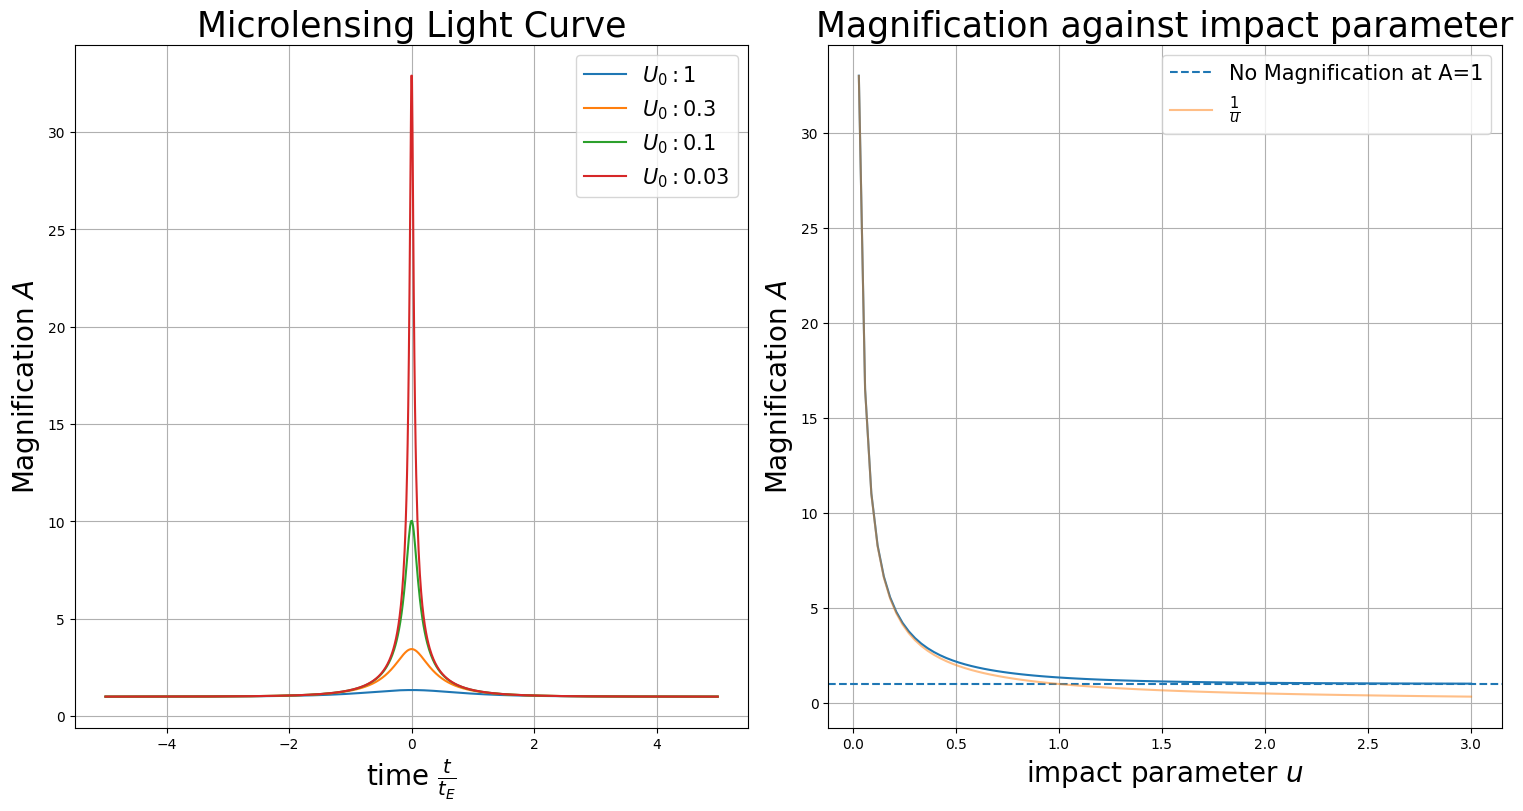

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def U_function_against_time(t,u_0,t_0=0,t_E=1):
    return np.sqrt(u_0**2 + ( (t-t_0) /t_E) **2 )

def A_function_against_U(u):
    return ((u**2+2) / (u*np.sqrt(u**2 + 4)))

t_E=1
t=np.linspace(-5,5,1000)*t_E


fig,ax=plt.subplots(1,2,figsize=(15,8),layout='constrained')
ax[0].set_title('Microlensing Light Curve',fontsize=25)
ax[0].set_xlabel('time $\\frac{t}{t_{E}}$',fontsize=20)
ax[0].set_ylabel('Magnification $A$',fontsize=20)
ax[0].grid()


u_0s=[1,0.3,0.1,0.03]
for u in u_0s:
    U=U_function_against_time(t,u_0=u,t_E=t_E)
    A=A_function_against_U(U)
    ax[0].plot(t,A,label=f'$U_{0}:{u}$')

u_0s=np.linspace(0,3,100)
ax[1].plot(u_0s,A_function_against_U(u_0s))
ax[1].grid()
ax[1].set_title('Magnification against impact parameter',fontsize=25)
ax[1].set_xlabel('impact parameter $u$',fontsize=20)
ax[1].set_ylabel('Magnification $A$',fontsize=20)
ax[1].axhline(1,linestyle='dashed',label='No Magnification at A=1')
ax[1].plot(u_0s,1/u_0s,label='$\\frac{1}{u}$',alpha=0.5)

ax[0].legend(fontsize=15)
ax[1].legend(fontsize=15)
plt.show()






# Task 4

For Large Magellenic Cloud, Optical Depth=5.630351442303129e-07
For Small Magellenic Cloud, Optical Depth=7.861169786019515e-07
For Galactic Bulge, Optical Depth=1.426966841310739e-07
For Andromeda Galaxy, Optical Depth=1.5918440705213184e-06


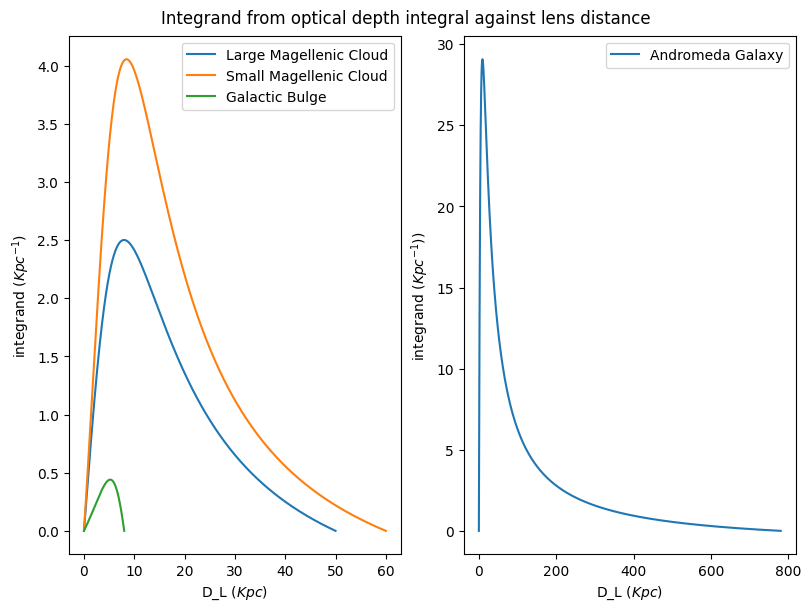

----------------------------------
fractions of dark matter in MACHOs
----------------------------------


In [3]:

def Optical_depth(coordinates,D_L,a=5,R_0=8,rho_0=0.01*10**9):
    #1kpc=1000pc
    #1 solar mass per cubic parsec = 10^9 solar masses per cubic kiloparsec
    D_S=np.max(D_L)
    r_squared=D_L**2+R_0**2-2*D_L*R_0*np.cos(coordinates['b'])*np.cos(coordinates['l'])
    constants=(4*np.pi*6.67*10**-11)*rho_0*(a**2+R_0**2)/((3*10**8)**2*D_S)
    integrand=D_L*(D_S-D_L)/(a**2+r_squared)
    return constants*np.trapezoid(integrand,x=D_L)*(2*10**30)/(3.09*10**19),(integrand,D_L)


distances=[np.linspace(0,50,5000),np.linspace(0,60,5000),np.linspace(0,8,5000),np.linspace(0,780,5000)]
coordinates=[{'l':280*np.pi/180,'b':-33*np.pi/180},{'l':303*np.pi/180,'b':-44*np.pi/180},{'l':1*np.pi/180,'b':-4*np.pi/180},{'l':121*np.pi/180,'b':-22*np.pi/180}]
names=['Large Magellenic Cloud','Small Magellenic Cloud','Galactic Bulge','Andromeda Galaxy']

fig,ax=plt.subplots(1,2,figsize=(8,6),layout='constrained')

for i in range(len(names)):
    depth,graph_values=Optical_depth(coordinates[i],distances[i])
    print(f'For {names[i]}, Optical Depth={depth}')
    if i==3:
        ax[1].plot(graph_values[1],graph_values[0],label=names[i])
    else:
        ax[0].plot(graph_values[1],graph_values[0],label=names[i])


ax[1].set_xlabel('D_L $(Kpc)$')
ax[0].set_xlabel('D_L $(Kpc)$')
ax[1].set_ylabel('integrand $(Kpc^{-1})$)')
ax[0].set_ylabel('integrand $(Kpc^{-1})$')
ax[0].legend()
ax[1].legend()
plt.suptitle('Integrand from optical depth integral against lens distance')

plt.show()

# tau must be less than or equal to 10^-7, so we can work out f - the fraction of dark matter in the halo

print('----------------------------------')
print('fractions of dark matter in MACHOs')
print('----------------------------------')

